In [100]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from typing import List, Any
from pandas.core.frame import DataFrame
from pandas import Series
from scipy.stats import pearsonr

import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler, PowerTransformer, StandardScaler
import os 

In [150]:
stock_paths = os.listdir('data_stock')
stock_paths = {
    stock_path.split('_')[1]: f'data_stock/{stock_path}' for stock_path in stock_paths
}
stock_paths

{'KDH': 'data_stock/final_KDH_RRC.csv',
 'CTS': 'data_stock/final_CTS_RRC.csv',
 'ITD': 'data_stock/final_ITD_RRC.csv',
 'CMG': 'data_stock/final_CMG_RRV.csv',
 'MSN': 'data_stock/final_MSN_RRV.csv',
 'PVS': 'data_stock/final_PVS_RRV.csv',
 'PVD': 'data_stock/final_PVD_RRV.csv',
 'MWG': 'data_stock/final_MWG_RRC.csv',
 'FPT': 'data_stock/final_FPT_RRV.csv',
 'VCB': 'data_stock/final_VCB_RRV.csv',
 'POT': 'data_stock/final_POT_RRC.csv',
 'HAG': 'data_stock/final_HAG_RRC.csv',
 'VNM': 'data_stock/final_VNM_RRV.csv',
 'PVB': 'data_stock/final_PVB_RRC.csv',
 'VIC': 'data_stock/final_VIC_RRV.csv',
 'CTG': 'data_stock/final_CTG_RRV.csv',
 'PDR': 'data_stock/final_PDR_RRC.csv',
 'NLG': 'data_stock/final_NLG_RRV.csv',
 'NVB': 'data_stock/final_NVB_RRC.csv',
 'PVC': 'data_stock/final_PVC_RRC.csv'}

In [ ]:
def clean_data(df: DataFrame) -> DataFrame:
    remove_features: list[str] = ['date', 'symbol', 'open', 'high', 'low', 'change']
    df: DataFrame = df.drop(columns=remove_features, errors='ignore')

    return df 

stock_dfs = {
    stock_name: clean_data(pd.read_csv(stock_path)) for stock_name, stock_path in stock_paths.items()
}

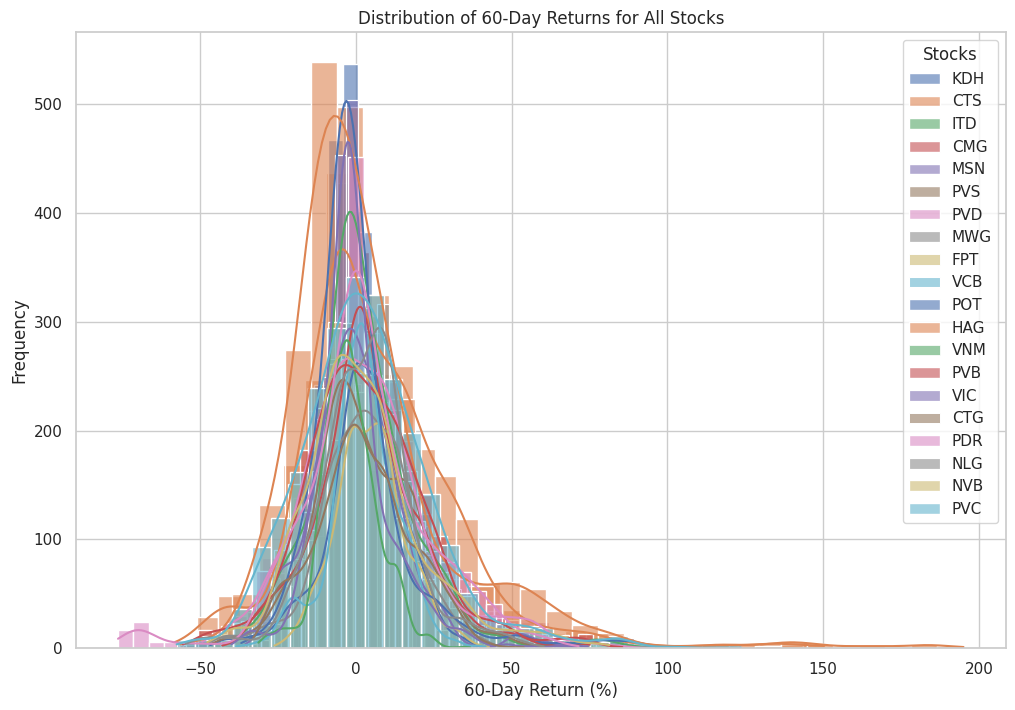

In [152]:
for stock_name, df in stock_dfs.items():
    df['price_shift_60'] = df['close'].shift(-60)
    df['return_60'] = (df['price_shift_60'] - df['close'])*100/df['close']
    stock_dfs[stock_name] = df.dropna(subset=['price_shift_60'], axis=0)

plt.figure(figsize=(12, 8))

# Loop through each stock and plot its 60-day return distribution using seaborn
for stock_name, df in stock_dfs.items():
    sns.histplot(df['return_60'], bins=30, kde=True, label=stock_name, alpha=0.6)

# Customize the plot
plt.title('Distribution of 60-Day Returns for All Stocks')
plt.xlabel('60-Day Return (%)')
plt.ylabel('Frequency')
plt.legend(title='Stocks')
plt.grid(True)
plt.show()

Mean of 20th Percentile across all stocks: -9.575430972797712
Mean of 40th Percentile across all stocks: -2.190117078567754
Mean of 60th Percentile across all stocks: 4.642340593708883
Mean of 80th Percentile across all stocks: 13.915902337191298


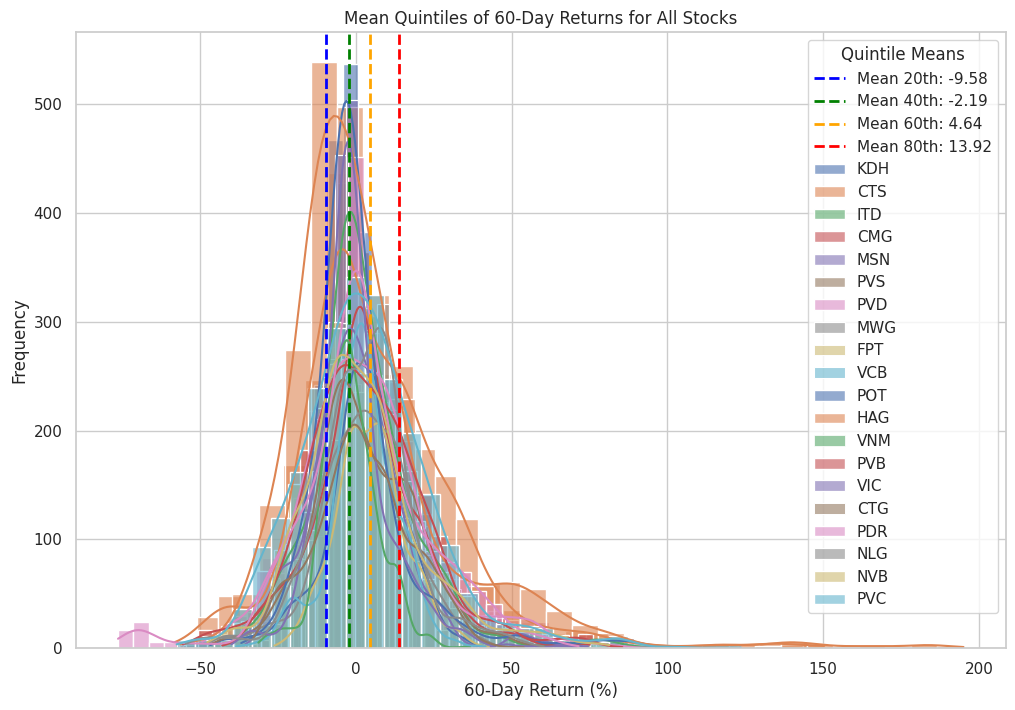

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Initialize lists to store quintile values for all stocks
quintiles_20th = []
quintiles_40th = []
quintiles_60th = []
quintiles_80th = []

# Set up the plot
plt.figure(figsize=(12, 8))

# Loop through each stock and plot its 60-day return distribution using seaborn
for stock_name, df in stock_dfs.items():
    # Plot histogram with KDE using seaborn
    sns.histplot(df['return_60'], bins=30, kde=True, label=stock_name, alpha=0.6)
    
    # Calculate the quintiles (20th, 40th, 60th, and 80th percentiles)
    quintiles = np.percentile(df['return_60'].dropna(), [20, 40, 60, 80])
    
    # Append quintile values to the respective lists
    quintiles_20th.append(quintiles[0])
    quintiles_40th.append(quintiles[1])
    quintiles_60th.append(quintiles[2])
    quintiles_80th.append(quintiles[3])

# Calculate the mean of each quintile across all stocks
mean_20th = np.mean(quintiles_20th)
mean_40th = np.mean(quintiles_40th)
mean_60th = np.mean(quintiles_60th)
mean_80th = np.mean(quintiles_80th)

# Print the mean of each quintile
print(f"Mean of 20th Percentile across all stocks: {mean_20th}")
print(f"Mean of 40th Percentile across all stocks: {mean_40th}")
print(f"Mean of 60th Percentile across all stocks: {mean_60th}")
print(f"Mean of 80th Percentile across all stocks: {mean_80th}")

plt.axvline(x=mean_20th, color='blue', linestyle='--', linewidth=2, label=f'Mean 20th: {mean_20th:.2f}')
plt.axvline(x=mean_40th, color='green', linestyle='--', linewidth=2, label=f'Mean 40th: {mean_40th:.2f}')
plt.axvline(x=mean_60th, color='orange', linestyle='--', linewidth=2, label=f'Mean 60th: {mean_60th:.2f}')
plt.axvline(x=mean_80th, color='red', linestyle='--', linewidth=2, label=f'Mean 80th: {mean_80th:.2f}')

# Customize the plot
plt.title('Mean Quintiles of 60-Day Returns for All Stocks')
plt.xlabel('60-Day Return (%)')
plt.ylabel('Frequency')
plt.legend(title='Quintile Means')
plt.grid(True)
plt.show()


tính trung bình từng phân vị của tất cả các mã cổ phiếu lấy ra được 5 khoảng tương ứng với 5 label:
- tăng mạnh: > 15%
- tăng nhẹ: 5 -> 15%
- ổn định: -3 -> 5%
- giảm nhẹ: -11 -> -3%
- giảm mạnh: < -11%

*Note: can tinh lai khi chia nhom cho cac ma

/tmp/ipykernel_6079/1006627037.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.index, y=feature_importances.values, palette='coolwarm')


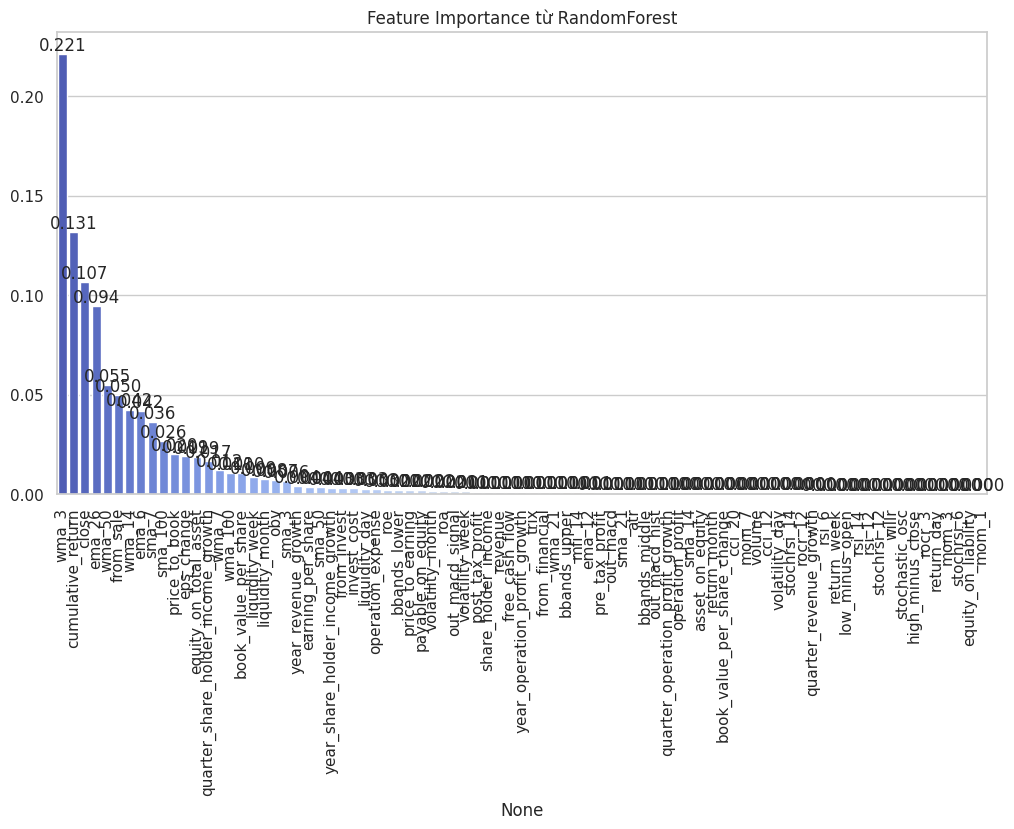

In [106]:
def feature_selection_random_forest(df: DataFrame, target_col: str, visualize: bool=True, top_k: float=0.3) -> List[str]:
    """
    Chọn top K% features dựa trên RandomForest.

    Parameters:
    - df: DataFrame chứa dữ liệu
    - target_col: Cột target (ví dụ: 'close')
    - visualize: Có vẽ biểu đồ không
    - top_k: Tỷ lệ feature cần chọn (mặc định là 30%)

    Returns:
    - Danh sách feature được chọn
    """
    # Xử lý dữ liệu bị thiếu
    df = df.dropna()

    X = df.drop(columns=[target_col])  # Features
    y = df[target_col]  # Target

    # Kiểm tra nếu không đủ dữ liệu để train
    if X.shape[1] == 0 or len(y.unique()) < 2:
        print("⚠️ Không đủ dữ liệu để chạy RandomForest!")
        return []

    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    rf.fit(X, y)

    # Lấy importance score
    feature_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

    # Sắp xếp giảm dần và chọn top K% feature
    num_features = max(1, int(len(feature_importances) * top_k))  # Ít nhất 1 feature
    top_features = feature_importances.nlargest(num_features).index.tolist()  # Lấy top feature

    if visualize:
        # 🔹 Vẽ biểu đồ Feature Importance
        plt.figure(figsize=(12,6))
        sns.barplot(x=feature_importances.index, y=feature_importances.values, palette='coolwarm')
        plt.xticks(rotation=90)
        plt.title("Feature Importance từ RandomForest")

        # Hiển thị giá trị trên từng cột
        for index, value in enumerate(feature_importances):
            plt.text(index, value, f"{value:.3f}", ha='center', va='bottom')

        plt.show()
    
    return top_features

df = stock_dfs['CMG']
top_features = feature_selection_random_forest(df, 'price_shift_60', visualize=True, top_k=0.3)
df = df[top_features + ['price_shift_60']]

In [107]:
def create_dataset(features, label, lookback):
    X = np.array([features[i : i + lookback] for i in range(len(features) - lookback)])
    y = np.array([label[i + lookback] for i in range(len(features) - lookback)])
    return X, y

In [124]:
lookback = 150

scaler = StandardScaler()
y_scaler = MinMaxScaler(feature_range=(0, 1))
power_transformer = PowerTransformer(method='yeo-johnson')

x_shift_30 = df.drop(columns=['price_shift_60'])
y_shift_30 = df['price_shift_60']

x_shift_30 = scaler.fit_transform(x_shift_30).reshape(x_shift_30.shape)
y_shift_30 = y_scaler.fit_transform(y_shift_30.to_frame())
y_shift_30 = power_transformer.fit_transform(y_shift_30).reshape(-1)

x_shift_30, y_shift_30 = create_dataset(x_shift_30, y_shift_30, lookback)

# --- Chia train/test ---
split = int(len(x_shift_30) * 0.85)  # 80% train, 20% test
X_train, X_test = x_shift_30[:split], x_shift_30[split:]
y_train, y_test = y_shift_30[:split], y_shift_30[split:]

print("Dữ liệu train:", X_train.shape, y_train.shape)
print("Dữ liệu test:", X_test.shape, y_test.shape)

Dữ liệu train: (1994, 150, 24) (1994,)
Dữ liệu test: (353, 150, 24) (353,)


In [125]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Conv1D, Dense, Dropout, Flatten, BatchNormalization
from keras.regularizers import l2


# Kiểm tra đầu vào
print("X_train shape:", X_train.shape)  # (samples, lookback, features)
print("y_train shape:", y_train.shape)  # (samples,)

X_train shape: (1994, 150, 24)
y_train shape: (1994,)


In [127]:
def invert_data(data):
    data = power_transformer.inverse_transform(data.reshape(-1, 1))
    data = y_scaler.inverse_transform(data)
    return data

In [ ]:
def build_lstm():
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        BatchNormalization(),
        Dropout(0.2),
        LSTM(32, return_sequences=True),
        BatchNormalization(),
        LSTM(32),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1)
    ])

    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model

model_lstm = build_lstm()
model_lstm.summary()

/home/panbooo/Codespace/hkt/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_96 (LSTM)                  │ (None, 150, 64)        │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 150, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 150, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_97 (LSTM)                  │ (None, 150, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 150, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_98 (LSTM)                  │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,633 (178.25 KB)

 Trainable params: 45,441 (177.50 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.4098 - mae: 0.4454 - val_loss: 0.9905 - val_mae: 0.8396
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0584 - mae: 0.1743 - val_loss: 0.9433 - val_mae: 0.7987
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 0.0334 - mae: 0.1326 - val_loss: 0.5287 - val_mae: 0.5620
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0287 - mae: 0.1261 - val_loss: 0.7057 - val_mae: 0.6707
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0275 - mae: 0.1180 - val_loss: 0.4467 - val_mae: 0.4920
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0243 - mae: 0.1114 - val_loss: 0.6347 - val_mae: 0.6199
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 0.0227 - mae: 0.1096 - val_loss: 0.3716 - val_mae: 0.4501
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0229 - mae: 0.1103 - val_loss: 0.4051 - val_mae: 0.5075
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - l

In [28]:
def build_gru():
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),  
        Dropout(0.2),
        GRU(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model

model_gru = build_gru()
model_gru.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 90, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,921 (116.88 KB)

 Trainable params: 29,921 (116.88 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
def build_lstm_cnn():
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),  
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model

model_lstm_cnn = build_lstm_cnn()
model_lstm_cnn.summary()


/home/panbooo/Codespace/hkt/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 88, 64)         │         7,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 88, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 88, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,345 (208.38 KB)

 Trainable params: 53,345 (208.38 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
def build_lstm_gru():
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),  
        Dropout(0.2),
        GRU(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model

model_lstm_gru = build_lstm_gru()
model_lstm_gru.summary()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 90, 64)         │        26,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,321 (141.88 KB)

 Trainable params: 36,321 (141.88 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

# Cài đặt EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss',  # Theo dõi validation loss
                               patience=10,        # Số epoch không cải thiện trước khi dừng
                               verbose=1,          # Hiển thị quá trình dừng
                               restore_best_weights=True)  # Khôi phục mô hình tốt nhất

EPOCHS = 50
BATCH_SIZE = 8

# Huấn luyện mô hình với EarlyStopping
history_lstm = model_lstm.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, 
                              validation_data=(X_test, y_test), callbacks=[early_stopping])

history_gru = model_gru.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, 
                            validation_data=(X_test, y_test), callbacks=[early_stopping])

history_lstm_cnn = model_lstm_cnn.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, 
                                      validation_data=(X_test, y_test), callbacks=[early_stopping])

history_lstm_gru = model_lstm_gru.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, 
                                      validation_data=(X_test, y_test), callbacks=[early_stopping])


Epoch 1/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0102 - mae: 0.0748 - val_loss: 0.0036 - val_mae: 0.0551
Epoch 2/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0043 - mae: 0.0495 - val_loss: 0.0018 - val_mae: 0.0367
Epoch 3/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0033 - mae: 0.0429 - val_loss: 0.0020 - val_mae: 0.0399
Epoch 4/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0030 - mae: 0.0403 - val_loss: 0.0019 - val_mae: 0.0383
Epoch 5/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0024 - mae: 0.0356 - val_loss: 0.0019 - val_mae: 0.0394
Epoch 6/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0023 - mae: 0.0355 - val_loss: 0.0015 - val_mae: 0.0341
Epoch 7/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0021 - mae: 0.0345 - val_loss: 0.0013 - val_mae: 0.0327
Epoch 8/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0016 - mae: 0.0300 - val_loss: 9.9007e-04 - val_mae: 0.0265
Epoch 9/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 

In [33]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
import numpy as np

# Dự đoán giá trị cho các mô hình
y_pred_lstm = model_lstm.predict(X_test)
y_pred_gru = model_gru.predict(X_test)
y_pred_lstm_cnn = model_lstm_cnn.predict(X_test)
y_pred_lstm_gru = model_lstm_gru.predict(X_test)

# Tính MAPE, RMSE và R² cho từng mô hình
def calculate_metrics(y_true, y_pred):
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100  # MAPE theo %
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # RMSE
    r2 = r2_score(y_true, y_pred)  # R²
    return mape, rmse, r2

# LSTM
mape_lstm, rmse_lstm, r2_lstm = calculate_metrics(y_test, y_pred_lstm)
# GRU
mape_gru, rmse_gru, r2_gru = calculate_metrics(y_test, y_pred_gru)
# LSTM + CNN
mape_lstm_cnn, rmse_lstm_cnn, r2_lstm_cnn = calculate_metrics(y_test, y_pred_lstm_cnn)
# LSTM + GRU
mape_lstm_gru, rmse_lstm_gru, r2_lstm_gru = calculate_metrics(y_test, y_pred_lstm_gru)

# In kết quả
print(f"LSTM MAPE: {mape_lstm:.2f}%, RMSE: {rmse_lstm:.2f}, R²: {r2_lstm:.2f}")
print(f"GRU MAPE: {mape_gru:.2f}%, RMSE: {rmse_gru:.2f}, R²: {r2_gru:.2f}")
print(f"LSTM + CNN MAPE: {mape_lstm_cnn:.2f}%, RMSE: {rmse_lstm_cnn:.2f}, R²: {r2_lstm_cnn:.2f}")
print(f"LSTM + GRU MAPE: {mape_lstm_gru:.2f}%, RMSE: {rmse_lstm_gru:.2f}, R²: {r2_lstm_gru:.2f}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
LSTM MAPE: 51.53%, RMSE: 0.03, R²: -0.27
GRU MAPE: 53.11%, RMSE: 0.03, R²: -0.42
LSTM + CNN MAPE: 60.03%, RMSE: 0.04, R²: -0.78
LSTM + GRU MAPE: 42.66%, RMSE: 0.03, R²: -0.37
